In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [38]:
df=pd.read_csv("spam_data.csv")

In [39]:
df

,message,spam_keywords,avg_word_length,special_symbols,repeated_words,capital_letters,phishing_words,label
0,WIN WIN WIN CASH OFFER!!!,4,4.2821,2,3,19,1,1
1,VERIFY YOUR BANK ACCOUNT NOW$$$,0,5.0159,4,0,17,3,1
2,CLIENT DISCUSSION RESCHEDULED,0,6.8388,0,1,1,0,0
3,PROJECT UPDATE SHARED WITH TEAM,1,6.2413,0,1,0,0,0
4,TEAM MEETING AGENDA ATTACHED,0,5.9159,1,0,0,0,0
...,...,...,...,...,...,...,...,...
145,TEAM MEETING AGENDA ATTACHED,0,6.7003,1,0,0,0,0
146,MEETING NOTES SHARED,0,6.1418,0,1,1,0,0
147,FREE BONUS MONEY WIN PRIZE!!!,6,3.8039,2,1,21,0,1
148,LUNCH PLAN CONFIRMED,1,4.9002,0,0,0,0,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   message          150 non-null    object 
 1   spam_keywords    150 non-null    int64  
 2   avg_word_length  150 non-null    float64
 3   special_symbols  150 non-null    int64  
 4   repeated_words   150 non-null    int64  
 5   capital_letters  150 non-null    int64  
 6   phishing_words   150 non-null    int64  
 7   label            150 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 9.5+ KB


In [41]:
df.describe()

,spam_keywords,avg_word_length,special_symbols,repeated_words,capital_letters,phishing_words,label
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.593333,5.400612,1.380000,0.753333,7.793333,0.893333,0.606667
std,1.734361,1.232024,1.403113,0.826870,8.876707,1.259310,0.490126
min,0.000000,3.338500,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.260400,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,5.571050,1.000000,1.000000,1.000000,0.000000,1.000000
75%,3.000000,6.441325,2.000000,1.000000,17.000000,1.000000,1.000000
max,6.000000,7.455200,4.000000,3.000000,26.000000,5.000000,1.000000


In [42]:
df.isna().sum()

message            0
spam_keywords      0
avg_word_length    0
special_symbols    0
repeated_words     0
capital_letters    0
phishing_words     0
label              0
dtype: int64

In [43]:
X=df.drop(columns=["message","label"])
y=df["label"]

In [44]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
lrmodel=LogisticRegression()
nbmodel=GaussianNB()

In [61]:
lrmodel.fit(X_train,y_train)

LogisticRegression()

In [62]:
nbmodel.fit(X_train,y_train)

GaussianNB()

In [47]:
lrpred=lrmodel.predict(X_test)
nbpred=nbmodel.predict(X_test)

In [48]:
print("Accuracy for the Logistic Regression model is :",round(accuracy_score(lrpred,y_test)*100,2))
print("Accuracy for the Naive Bayes model is :",round(accuracy_score(nbpred,y_test)*100,2))

Accuracy for the Logistic Regression model is : 100.0
Accuracy for the Naive Bayes model is : 93.33


In [29]:
print("Confusion matrix for LR :\n",confusion_matrix(y_test,lrpred))

Confusion matrix for LR :
 [[10  0]
 [ 0 20]]


In [50]:
print("Confusion matrix for NB :\n",confusion_matrix(y_test,nbpred))

Confusion matrix for NB :
 [[10  0]
 [ 2 18]]


In [ ]:
test=lrmodel.predict(np.array([[3,4.20,1,1,10,1]]))

In [55]:
test

array([1], dtype=int64)

In [59]:
with open("lrmodel.pkl", 'wb') as file:
    pickle.dump(lrmodel, file)

In [60]:
with open("nbmodel.pkl", 'wb') as file:
    pickle.dump(nbmodel, file)

In [4]:
import pandas as pd
import numpy as np
import random

# 1. Setup Data Parameters
num_rows = 200
# UPDATED: Limited to exactly 4 categories as requested
occupations = ['Student', 'Retired', 'Business Owner', 'Corporate Officer']

# 2. Generate Random Features
data = {
    'Customer_ID': [f'CUST_{i:03d}' for i in range(1, num_rows + 1)],
    
    # Complexity: 0 (Simple) to 10 (High Tech)
    'Basket_Complexity_Score': [round(random.uniform(0.1, 9.9), 1) for _ in range(num_rows)],
    
    # Stock Out: 10% chance of missing items
    'Stock_Out_Flag': [1 if random.random() < 0.1 else 0 for _ in range(num_rows)],
    
    # Demographics (Using new list)
    'Occupation': [random.choice(occupations) for _ in range(num_rows)],
    'Age': [random.randint(18, 80) for _ in range(num_rows)],
    
    # Address: Distance in km
    'Distance_From_Store_km': [round(random.triangular(0.5, 30.0, 2.0), 1) for _ in range(num_rows)],
    
    # Offers: 0=None, 1=Coupon, 2=Sale
    'Offers_Coupons': [random.choices([0, 1, 2], weights=[0.5, 0.2, 0.3])[0] for _ in range(num_rows)]
}

df = pd.DataFrame(data)

# 3. Generate Target Variable (Will_Repeat_In_Near_Future)
def generate_target(row):
    # Base probability
    score = 0.5
    
    # Rule 1: High Complexity risks churn (unless they have a coupon)
    if row['Basket_Complexity_Score'] > 7.0:
        score -= 0.3
    
    # Rule 2: Stock Outs are bad
    if row['Stock_Out_Flag'] == 1:
        score -= 0.4
        
    # Rule 3: Living close is good
    if row['Distance_From_Store_km'] < 3.0:
        score += 0.3
        
    # Rule 4: Coupons help
    if row['Offers_Coupons'] == 1:
        score += 0.25
    elif row['Offers_Coupons'] == 2:
        score += 0.1
        
    # Rule 5: Occupation Logic (Updated)
    # Students shop often (small needs)
    if row['Occupation'] == 'Student':
        score += 0.1
    # Business Owners shop often (supplies)
    elif row['Occupation'] == 'Business Owner':
        score += 0.15
    # Corporate Officers might be too busy (slight negative or neutral)
    elif row['Occupation'] == 'Corporate Officer':
        score -= 0.05
        
    # Cap probability and flip coin
    final_prob = max(0, min(1, score))
    return 1 if random.random() < final_prob else 0

df['Will_Repeat_In_Near_Future'] = df.apply(generate_target, axis=1)

# 4. Display and/or Save
print(df.head(10))
df.to_csv('mart_customer_data_v2.csv', index=False)

  Customer_ID  Basket_Complexity_Score  Stock_Out_Flag         Occupation  \
0    CUST_001                      0.2               0            Student   
1    CUST_002                      9.7               0     Business Owner   
2    CUST_003                      9.2               0            Student   
3    CUST_004                      0.2               0            Student   
4    CUST_005                      5.4               0            Student   
5    CUST_006                      6.7               0  Corporate Officer   
6    CUST_007                      9.5               0            Student   
7    CUST_008                      2.3               0            Retired   
8    CUST_009                      4.6               0  Corporate Officer   
9    CUST_010                      1.9               0            Retired   

   Age  Distance_From_Store_km  Offers_Coupons  Will_Repeat_In_Near_Future  
0   62                    11.8               0                           1 

In [5]:
df=pd.read_csv('mart_customer.csv')

In [8]:
X=df.drop(columns=['Customer_ID','Occupation','Will_Repeat_In_Near_Future'])

Data Generated Successfully!
Dataset Shape: (200, 8)
------------------------------
Preprocessing Complete.
Training Features: 9
------------------------------
Model Training Complete.
------------------------------
Model Accuracy: 0.75 (75.0%)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.56      0.64        16
           1       0.75      0.88      0.81        24

    accuracy                           0.75        40
   macro avg       0.75      0.72      0.73        40
weighted avg       0.75      0.75      0.74        40



C:\Users\umair\AppData\Local\Temp\ipykernel_2444\2310440650.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


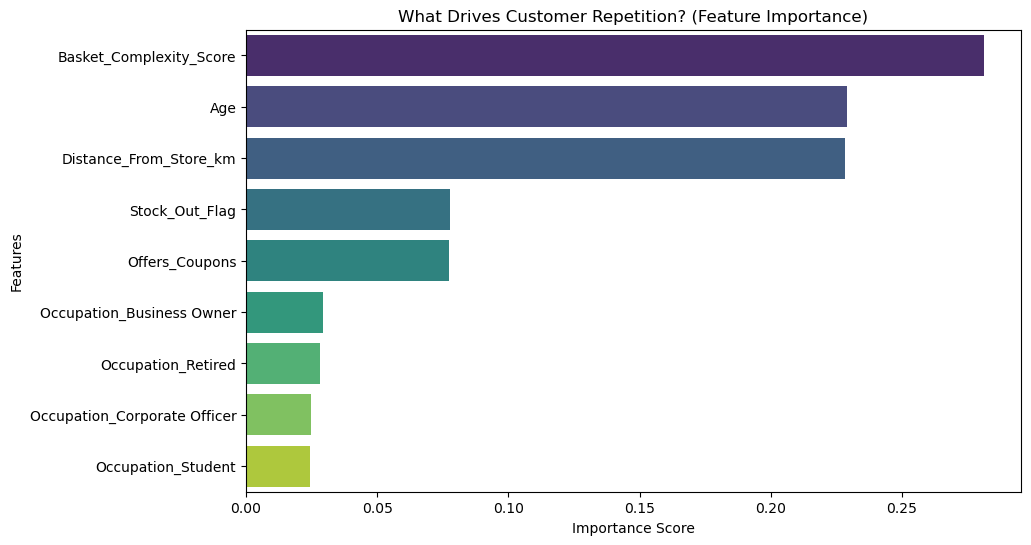

In [9]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# STEP 2: GENERATE THE DATASET (As defined previously)
# ==========================================
# We regenerate the data here so this script is self-contained
num_rows = 200
occupations = ['Student', 'Retired', 'Business Owner', 'Corporate Officer']

data = {
    'Customer_ID': [f'CUST_{i:03d}' for i in range(1, num_rows + 1)],
    'Basket_Complexity_Score': [round(random.uniform(0.1, 9.9), 1) for _ in range(num_rows)],
    'Stock_Out_Flag': [1 if random.random() < 0.1 else 0 for _ in range(num_rows)],
    'Occupation': [random.choice(occupations) for _ in range(num_rows)],
    'Age': [random.randint(18, 80) for _ in range(num_rows)],
    'Distance_From_Store_km': [round(random.triangular(0.5, 30.0, 2.0), 1) for _ in range(num_rows)],
    'Offers_Coupons': [random.choices([0, 1, 2], weights=[0.5, 0.2, 0.3])[0] for _ in range(num_rows)]
}

df = pd.DataFrame(data)

# Apply Logic to create the Target (Will_Repeat)
def generate_target(row):
    score = 0.5
    if row['Basket_Complexity_Score'] > 7.0: score -= 0.3
    if row['Stock_Out_Flag'] == 1: score -= 0.4
    if row['Distance_From_Store_km'] < 3.0: score += 0.3
    if row['Offers_Coupons'] == 1: score += 0.25
    elif row['Offers_Coupons'] == 2: score += 0.1
    if row['Occupation'] == 'Student': score += 0.1
    elif row['Occupation'] == 'Business Owner': score += 0.15
    elif row['Occupation'] == 'Corporate Officer': score -= 0.05
    final_prob = max(0, min(1, score))
    return 1 if random.random() < final_prob else 0

df['Will_Repeat_In_Near_Future'] = df.apply(generate_target, axis=1)

print("Data Generated Successfully!")
print(f"Dataset Shape: {df.shape}")
print("-" * 30)

# ==========================================
# STEP 3: DATA PREPROCESSING
# ==========================================
# 1. Drop ID Column (It doesn't help prediction)
df_clean = df.drop(columns=['Customer_ID'])

# 2. Convert Categorical Data to Numbers (One-Hot Encoding)
# The model cannot read "Student" or "Retired". We convert them into columns like "Occupation_Student" (0 or 1).
df_processed = pd.get_dummies(df_clean, columns=['Occupation'], drop_first=False)

# 3. Define Features (X) and Target (y)
X = df_processed.drop(columns=['Will_Repeat_In_Near_Future'])
y = df_processed['Will_Repeat_In_Near_Future']

# 4. Split into Training (80%) and Testing (20%) sets
# [cite_start]This ensures we test the model on "unseen" data[cite: 6].
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing Complete.")
print(f"Training Features: {X_train.shape[1]}")
print("-" * 30)

# ==========================================
# STEP 4: TRAIN RANDOM FOREST MODEL
# ==========================================
# We use Random Forest because it handles non-linear patterns (like Coupons + Distance) well.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model Training Complete.")
print("-" * 30)

# ==========================================
# STEP 5: EVALUATION & VISUALIZATION
# ==========================================
# Make Predictions
y_pred = rf_model.predict(X_test)

# 1. Print Accuracy Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f} ({accuracy*100}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 2. Visualize Feature Importance
# This tells you WHAT factors drive repetition (e.g., is Distance more important than Age?)
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for plotting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('What Drives Customer Repetition? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()